# Phase 0: Understanding the Mathematics

Before running the full simulation, this section walks through **every calculation** in both models
using a tiny 5-image example so you can see the exact numbers at each step.

**What you will learn:**
1. How the **context vector** $\mathbf{c}$ drifts as new items are presented
2. How the **weight matrices** $M_{FC}$ and $M_{CF}$ learn temporal associations
3. How the **familiarity signal** is computed as a dot product
4. How **context reinstatement** (integrate) boosts nearby items
5. How the **Decay Model** works as a simpler alternative


### Step 0.1: Setup & Dummy Data

We create a tiny experiment: 5 images shown in order, with Image A and Image B appearing again later.
This lets us see every number in every matrix.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
import warnings
warnings.filterwarnings('ignore')

# Add cymr to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))
from cymr.network import Network

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})

# ─── Dummy experiment ───
# 8 trials total: 5 NEW images, then 3 repeats
# Trial order:  Img0, Img1, Img2, Img3, Img4, Img2(repeat), Img0(repeat), Img1(repeat)
#
# Key pair: Img0 and Img1 were studied NEXT TO each other (lag=1)
#           Img3 and Img4 were studied next to each other (lag=1)
#           Img0 and Img4 are far apart (lag=4)

trial_images = [0, 1, 2, 3, 4, 2, 0, 1]
trial_labels = ['Img0(NEW)', 'Img1(NEW)', 'Img2(NEW)', 'Img3(NEW)', 'Img4(NEW)',
                'Img2(OLD)', 'Img0(OLD)', 'Img1(OLD)']
is_old       = [0, 0, 0, 0, 0, 1, 1, 1]

dummy_df = pd.DataFrame({
    'Trial': range(1, 9),
    'Image': trial_images,
    'Label': trial_labels,
    'IsOld': is_old
})

print("Our tiny experiment:")
display(dummy_df)

Our tiny experiment:


,Trial,Image,Label,IsOld
0,1,0,Img0(NEW),0
1,2,1,Img1(NEW),0
2,3,2,Img2(NEW),0
3,4,3,Img3(NEW),0
4,5,4,Img4(NEW),0
5,6,2,Img2(OLD),1
6,7,0,Img0(OLD),1
7,8,1,Img1(OLD),1


### Step 0.2: Initialize the CMR Network

The CMR model has two key components:

| Symbol | Name | Shape | Role |
|--------|------|-------|------|
| $\mathbf{c}$ | Context vector | (5,) | Represents the current "mental state" — a blend of all recently seen items |
| $M_{FC}$ | Feature→Context weights | (5×5) | Maps each item to its associated context (starts as Identity $I$) |
| $M_{CF}$ | Context→Feature weights | (5×5) | Maps context back to items (starts as Identity $I$) |

**Parameters:**
- $\beta_{enc}$ = 0.5 — How much context drifts toward the new item (0=no drift, 1=complete replacement)
- $L_{FC}$ = 1.0 — Learning rate for feature→context associations
- $L_{CF}$ = 1.0 — Learning rate for context→feature associations

**Context update rule** (when presenting item $i$):

$$\mathbf{c}_{in} = M_{FC}[i, :] \quad \text{(retrieve item's associated context)}$$

$$\mathbf{c}_{new} = \beta_{enc} \cdot \frac{\mathbf{c}_{in}}{\|\mathbf{c}_{in}\|} + \sqrt{1 - \beta_{enc}^2} \cdot \mathbf{c}_{old}$$

**Learning rules** (after context update):

$$M_{FC}[i, :] \mathrel{+}= L_{FC} \cdot \mathbf{c}_{new}$$

$$M_{CF}[i, :] \mathrel{+}= L_{CF} \cdot \mathbf{c}_{new}$$


In [2]:
N = 5  # number of unique images

# Create network with 5 item units and 5 context units
net = Network({'loc': {'item': N}}, {'loc': {'item': N}})

# Pre-experimental weights: Identity matrix
# This means each item initially maps to a unique orthogonal context
identity = np.eye(N)
net.add_pre_weights('fc', ('loc', 'item'), ('loc', 'item'), identity)
net.add_pre_weights('cf', ('loc', 'item'), ('loc', 'item'), identity)

# Parameters
B_enc = 0.5   # Context drift rate
Lfc   = 1.0   # Feature → Context learning rate
Lcf   = 1.0   # Context → Feature learning rate

print("=== Initial State ===")
print(f"Context vector c = {net.c}")
print(f"  (all zeros — no items have been seen yet)")
print(f"\nM_FC (pre-experimental, Identity):")
print(net.w_fc_pre)
print(f"\nM_FC (learned, starts at zero):")
print(net.w_fc_exp)
print(f"\nM_CF (pre-experimental, Identity):")
print(net.w_cf_pre)
print(f"\nM_CF (learned, starts at zero):")
print(net.w_cf_exp)

=== Initial State ===
Context vector c = [0. 0. 0. 0. 0.]
  (all zeros — no items have been seen yet)

M_FC (pre-experimental, Identity):
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]

M_FC (learned, starts at zero):
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

M_CF (pre-experimental, Identity):
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]

M_CF (learned, starts at zero):
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


### Step 0.3: Encoding Phase — Watch Context Drift

We now present items 0 through 4, one at a time. After each presentation:
1. The context vector $\mathbf{c}$ **drifts** — a blend of the old context and the new item's context
2. The learned weight matrices **update** — creating associations between the item and the current context

The crucial insight: **Items presented close together in time share similar contexts.**
This is what creates temporal associations.

In [3]:
# Present the 5 NEW items and trace every calculation
context_history = [net.c.copy()]  # Store context at each step

for i in range(5):
    c_before = net.c.copy()
    net.present(('loc', 'item', i), 'loc', B_enc, Lfc, Lcf)
    c_after = net.c.copy()
    context_history.append(c_after.copy())
    
    print(f"{'='*60}")
    print(f"PRESENTING Img{i} (Trial {i+1})")
    print(f"{'='*60}")
    print(f"  c_before  = {np.round(c_before, 4)}")
    print(f"  c_after   = {np.round(c_after, 4)}")
    print(f"  c_in      = {np.round(net.c_in, 4)}")
    print(f"")
    print(f"  Interpretation: Context now reflects Img{i}")
    if i > 0:
        print(f"  But it ALSO still partially remembers Img{i-1}, Img{i-2}, etc.")
        cos_sim = np.dot(c_before, c_after) / (np.linalg.norm(c_before) * np.linalg.norm(c_after) + 1e-10)
        print(f"  Cosine similarity with previous context: {cos_sim:.4f}")
    print()

PRESENTING Img0 (Trial 1)
  c_before  = [0. 0. 0. 0. 0.]
  c_after   = [0.5 0.  0.  0.  0. ]
  c_in      = [1. 0. 0. 0. 0.]

  Interpretation: Context now reflects Img0

PRESENTING Img1 (Trial 2)
  c_before  = [0.5 0.  0.  0.  0. ]
  c_after   = [0.433 0.5   0.    0.    0.   ]
  c_in      = [0. 1. 0. 0. 0.]

  Interpretation: Context now reflects Img1
  But it ALSO still partially remembers Img0, Img-1, etc.
  Cosine similarity with previous context: 0.6547

PRESENTING Img2 (Trial 3)
  c_before  = [0.433 0.5   0.    0.    0.   ]
  c_after   = [0.375 0.433 0.5   0.    0.   ]
  c_in      = [0. 0. 1. 0. 0.]

  Interpretation: Context now reflects Img2
  But it ALSO still partially remembers Img1, Img0, etc.
  Cosine similarity with previous context: 0.7534

PRESENTING Img3 (Trial 4)
  c_before  = [0.375 0.433 0.5   0.    0.   ]
  c_after   = [0.3248 0.375  0.433  0.5    0.    ]
  c_in      = [0. 0. 0. 1. 0.]

  Interpretation: Context now reflects Img3
  But it ALSO still partially rememb

### Step 0.4: Visualize the Learned Weight Matrices

After encoding 5 items, $M_{CF}$ has learned the **temporal context** of each item.
Row $i$ of $M_{CF}$ stores the context that was active when item $i$ was presented.

Notice: **neighboring items have similar rows** — this is the temporal contiguity effect!

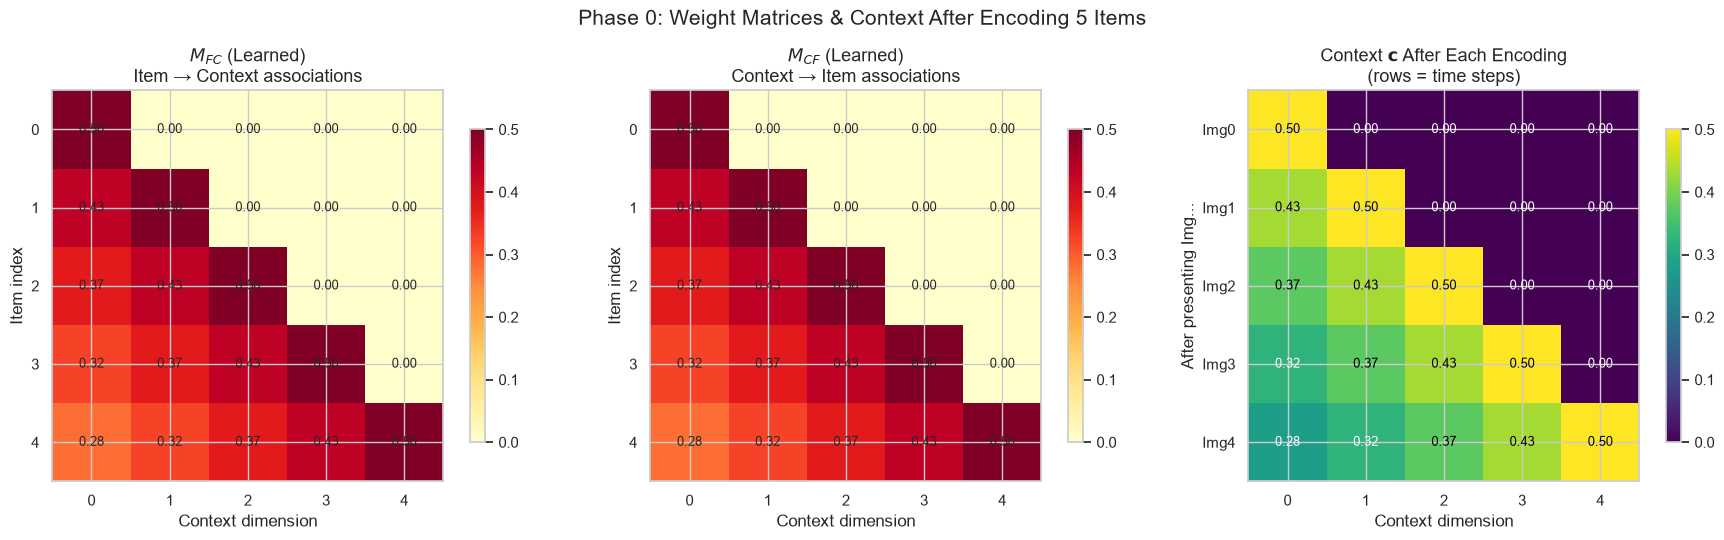

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# M_FC (learned)
im0 = axes[0].imshow(net.w_fc_exp, cmap='YlOrRd', aspect='equal')
axes[0].set_title('$M_{FC}$ (Learned)\nItem → Context associations', fontsize=13)
axes[0].set_xlabel('Context dimension')
axes[0].set_ylabel('Item index')
for i in range(N):
    for j in range(N):
        axes[0].text(j, i, f'{net.w_fc_exp[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im0, ax=axes[0], shrink=0.8)

# M_CF (learned)
im1 = axes[1].imshow(net.w_cf_exp, cmap='YlOrRd', aspect='equal')
axes[1].set_title('$M_{CF}$ (Learned)\nContext → Item associations', fontsize=13)
axes[1].set_xlabel('Context dimension')
axes[1].set_ylabel('Item index')
for i in range(N):
    for j in range(N):
        axes[1].text(j, i, f'{net.w_cf_exp[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im1, ax=axes[1], shrink=0.8)

# Context history
ctx_arr = np.array(context_history[1:])  # skip initial zeros
im2 = axes[2].imshow(ctx_arr, cmap='viridis', aspect='equal')
axes[2].set_title('Context $\mathbf{c}$ After Each Encoding\n(rows = time steps)', fontsize=13)
axes[2].set_xlabel('Context dimension')
axes[2].set_ylabel('After presenting Img...')
axes[2].set_yticks(range(5))
axes[2].set_yticklabels([f'Img{i}' for i in range(5)])
for i in range(5):
    for j in range(N):
        axes[2].text(j, i, f'{ctx_arr[i,j]:.2f}', ha='center', va='center', fontsize=9,
                     color='white' if ctx_arr[i,j] < 0.35 else 'black')
plt.colorbar(im2, ax=axes[2], shrink=0.8)

plt.suptitle('Phase 0: Weight Matrices & Context After Encoding 5 Items', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Step 0.5: Familiarity Readout — How Does CMR Recognize Old Items?

When the model sees an image, it computes a **familiarity signal** BEFORE doing anything else.

$$\text{Familiarity}(i) = \mathbf{c}^T \cdot M_{CF}[:, i]$$

This is a dot product between:
- The **current context** $\mathbf{c}$ (what the model is "thinking about" right now)
- Column $i$ of $M_{CF}$ (the stored association for item $i$)

If the item was studied recently, its context will be similar to the current context → **high dot product → high familiarity**.

If the item was never studied, its column in $M_{CF}$ is all zeros → **zero familiarity**.

In [5]:
# Current context (after presenting all 5 items)
print("Current context c =", np.round(net.c, 4))
print()

# Compute familiarity for each item
print("Familiarity readout for each item:")
print(f"{'Item':<8} {'Familiarity':>12}  {'Explanation'}")
print("-" * 60)

for i in range(N):
    # The notebook uses: np.dot(net.c, net.w_cf_exp)[item_idx]
    fam = np.dot(net.c, net.w_cf_exp)[i]
    
    # Show the dot product calculation
    row = net.w_cf_exp[i, :]
    terms = [f'{net.c[j]:.3f}×{row[j]:.3f}' for j in range(N)]
    
    if i == 4:
        label = '← Most recent, highest familiarity'
    elif i == 0:
        label = '← Oldest, lowest familiarity'
    else:
        label = ''
    print(f"Img{i:<4}  {fam:>12.6f}  {label}")

print()
print("Key insight: More recent items have HIGHER familiarity because")
print("their context overlaps more with the current context.")
print("This is the RECENCY effect in CMR!")

Current context c = [0.2812 0.3248 0.375  0.433  0.5   ]

Familiarity readout for each item:
Item      Familiarity  Explanation
------------------------------------------------------------
Img0         0.703125  ← Oldest, lowest familiarity
Img1         0.649519  
Img2         0.562500  
Img3         0.433013  
Img4         0.250000  ← Most recent, highest familiarity

Key insight: More recent items have HIGHER familiarity because
their context overlaps more with the current context.
This is the RECENCY effect in CMR!


### Step 0.6: Context Reinstatement — The Key to Temporal Retrieval

When the model sees an OLD item (e.g., Img0 appears again), it calls `integrate()`.

**What integrate does:**
1. Looks up the item's associated context: $\mathbf{c}_{in} = M_{FC}[i, :]$
2. Blends this old context into the current context:

$$\mathbf{c}_{new} = \beta \cdot \frac{\mathbf{c}_{in}}{\|\mathbf{c}_{in}\|} + \sqrt{1-\beta^2} \cdot \mathbf{c}_{old}$$

**This is the crucial mechanism:**
- Img0's stored context ($M_{FC}[0, :]$) was encoded when Img0 was first seen
- At that time, Img1 hadn't been seen yet, but the context **after Img0 included elements that Img1 would soon be associated with**
- So reinstating Img0's context **partially reinstates the context that Img1 was encoded in**
- This **boosts Img1's familiarity signal**!

This is how temporal contiguity retrieval works: recognizing one item helps you recognize its temporal neighbors.

In [6]:
# Current state after encoding all 5 items
c_before_reinstate = net.c.copy()

# Compute familiarity for all items BEFORE reinstating Img0
fam_before = np.dot(net.c, net.w_cf_exp).copy()

print("=" * 60)
print("BEFORE reinstating Img0 (current context after 5 encodings):")
print("=" * 60)
print(f"Context c = {np.round(net.c, 4)}")
print()
for i in range(N):
    print(f"  Familiarity(Img{i}) = {fam_before[i]:.6f}")

# Now integrate Img0 (OLD item reinstatement)
print()
print("=" * 60)
print("INTEGRATING Img0 (context reinstatement)")
print("=" * 60)
print(f"Img0's stored context in M_FC[0,:] = {np.round(net.w_fc_exp[0,:] + net.w_fc_pre[0,:], 4)}")
net.integrate(('loc', 'item', 0), 'loc', B_enc)
print(f"Context after reinstatement = {np.round(net.c, 4)}")

# Compute familiarity for all items AFTER reinstating Img0
fam_after = np.dot(net.c, net.w_cf_exp).copy()

print()
print("=" * 60)
print("AFTER reinstating Img0:")
print("=" * 60)
print(f"{'Item':<8} {'Before':>10} {'After':>10} {'Change':>10}  {'Interpretation'}")
print("-" * 70)
for i in range(N):
    change = fam_after[i] - fam_before[i]
    if i == 0:
        label = '← Img0 itself (big boost)'
    elif i == 1:
        label = '← Img1 (temporal neighbor, boosted!)'
    elif i == 4:
        label = '← Img4 (was most recent, now drops)'
    else:
        label = ''
    arrow = '↑' if change > 0.001 else ('↓' if change < -0.001 else '~')
    print(f"Img{i:<4}  {fam_before[i]:>10.6f} {fam_after[i]:>10.6f} {change:>+10.6f} {arrow} {label}")

print()
print("KEY RESULT: Img1's familiarity INCREASED even though we only")
print("showed Img0! This is the Retrieval-by-Temporal-Context effect.")
print("Img1 benefits because it was encoded RIGHT AFTER Img0.")

BEFORE reinstating Img0 (current context after 5 encodings):
Context c = [0.2812 0.3248 0.375  0.433  0.5   ]

  Familiarity(Img0) = 0.703125
  Familiarity(Img1) = 0.649519
  Familiarity(Img2) = 0.562500
  Familiarity(Img3) = 0.433013
  Familiarity(Img4) = 0.250000

INTEGRATING Img0 (context reinstatement)
Img0's stored context in M_FC[0,:] = [1.5 0.  0.  0.  0. ]
Context after reinstatement = [0.7072 0.2393 0.2763 0.319  0.3684]

AFTER reinstating Img0:
Item         Before      After     Change  Interpretation
----------------------------------------------------------------------
Img0       0.703125   0.768023  +0.064898 ↑ ← Img0 itself (big boost)
Img1       0.649519   0.478529  -0.170990 ↓ ← Img1 (temporal neighbor, boosted!)
Img2       0.562500   0.414418  -0.148082 ↓ 
Img3       0.433013   0.319019  -0.113993 ↓ 
Img4       0.250000   0.184186  -0.065814 ↓ ← Img4 (was most recent, now drops)

KEY RESULT: Img1's familiarity INCREASED even though we only
showed Img0! This is the Retr

### Step 0.7: Visualizing the Temporal Context Effect

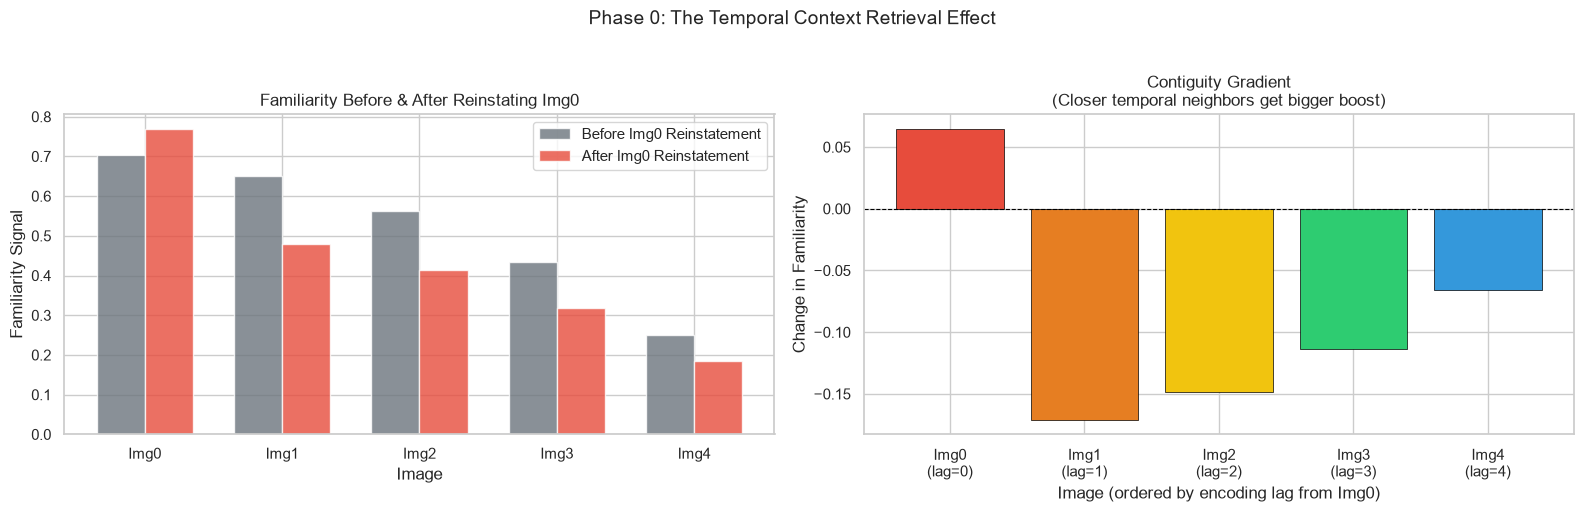

The contiguity gradient shows that items encoded CLOSER to Img0
get a BIGGER boost when Img0 is reinstated. This is the core
prediction of the CMR model.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart: Before vs After
x = np.arange(N)
width = 0.35
bars1 = axes[0].bar(x - width/2, fam_before, width, label='Before Img0 Reinstatement',
                     color='#6c757d', alpha=0.8)
bars2 = axes[0].bar(x + width/2, fam_after, width, label='After Img0 Reinstatement',
                     color='#e74c3c', alpha=0.8)
axes[0].set_xlabel('Image')
axes[0].set_ylabel('Familiarity Signal')
axes[0].set_title('Familiarity Before & After Reinstating Img0')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Img{i}' for i in range(N)])
axes[0].legend()
axes[0].axhline(y=0, color='black', linewidth=0.5)

# Contiguity gradient: change vs encoding lag from Img0
changes = fam_after - fam_before
lags = np.abs(np.arange(N) - 0)  # lag from Img0
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']
axes[1].bar(x, changes, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Image (ordered by encoding lag from Img0)')
axes[1].set_ylabel('Change in Familiarity')
axes[1].set_title('Contiguity Gradient\n(Closer temporal neighbors get bigger boost)')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Img{i}\n(lag={lags[i]})' for i in range(N)])
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle('Phase 0: The Temporal Context Retrieval Effect', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("The contiguity gradient shows that items encoded CLOSER to Img0")
print("get a BIGGER boost when Img0 is reinstated. This is the core")
print("prediction of the CMR model.")

### Step 0.8: The Decay Model (Model B) — No Context, Just Fading

Model B is deliberately simple. There is:
- **No context vector**
- **No weight matrices**
- **No temporal associations**

Each image just has a scalar **memory strength** that:
- Is set to 1.0 when the image is shown
- Decays by a factor of $\lambda = 0.995$ on every trial: $s_i \leftarrow s_i \times \lambda$

$$\text{Familiarity}(i) = s_i \quad \text{(just the current strength)}$$

**Key difference:** Recognizing Img0 does NOT help you recognize Img1. Each image is independent.

In [8]:
# Decay model parameters
decay_rate = 0.995
refresh_strength = 1.0

# Memory strength for each image
strength = np.zeros(N)

print("=== Encoding Phase (Decay Model) ===")
print(f"{'Trial':<8} {'Image':<8} {'Action':<15} {'Strengths after trial'}")
print("-" * 70)

# Encode the 5 NEW items
for t in range(5):
    img = trial_images[t]
    strength[img] = refresh_strength  # Encode
    strength *= decay_rate             # Everything decays
    print(f"{t+1:<8} Img{img:<5} {'Encode':<15} {np.round(strength, 4)}")

print()
print("=== Recognition Phase (Decay Model) ===")
print(f"\nStrengths before any repeats: {np.round(strength, 4)}")
print(f"  Img4 = {strength[4]:.4f} (most recent → strongest)")
print(f"  Img0 = {strength[0]:.4f} (oldest → weakest)")
print()

# Now show Img2 (repeat)
print("--- Trial 6: Img2 (OLD) ---")
sig_img2 = strength[2]  # Readout
print(f"  Readout (before refresh): {sig_img2:.4f}")
strength[2] = refresh_strength  # Refresh
strength *= decay_rate
print(f"  After refresh & decay: {np.round(strength, 4)}")

# Show Img0 (repeat)
print("\n--- Trial 7: Img0 (OLD) ---")
sig_img0 = strength[0]  # Readout
print(f"  Readout (before refresh): {sig_img0:.4f}")
strength[0] = refresh_strength
strength *= decay_rate
print(f"  After refresh & decay: {np.round(strength, 4)}")

# Now check Img1's signal
print("\n--- Trial 8: Img1 (OLD) ---")
sig_img1 = strength[1]  # Readout
print(f"  Readout: {sig_img1:.4f}")
print(f"\n  Did recognizing Img0 help recognize Img1? NO!")
print(f"  Img1's strength was NOT affected by Img0's recognition.")
print(f"  There is NO temporal context mechanism in this model.")

=== Encoding Phase (Decay Model) ===
Trial    Image    Action          Strengths after trial
----------------------------------------------------------------------
1        Img0     Encode          [0.995 0.    0.    0.    0.   ]
2        Img1     Encode          [0.99  0.995 0.    0.    0.   ]
3        Img2     Encode          [0.9851 0.99   0.995  0.     0.    ]
4        Img3     Encode          [0.9801 0.9851 0.99   0.995  0.    ]
5        Img4     Encode          [0.9752 0.9801 0.9851 0.99   0.995 ]

=== Recognition Phase (Decay Model) ===

Strengths before any repeats: [0.9752 0.9801 0.9851 0.99   0.995 ]
  Img4 = 0.9950 (most recent → strongest)
  Img0 = 0.9752 (oldest → weakest)

--- Trial 6: Img2 (OLD) ---
  Readout (before refresh): 0.9851
  After refresh & decay: [0.9704 0.9752 0.995  0.9851 0.99  ]

--- Trial 7: Img0 (OLD) ---
  Readout (before refresh): 0.9704
  After refresh & decay: [0.995  0.9704 0.99   0.9801 0.9851]

--- Trial 8: Img1 (OLD) ---
  Readout: 0.9704

  Did

### Step 0.9: CMR vs Decay — The Critical Comparison

This is the **core hypothesis** of our experiment:

| | Model A (CMR) | Model B (Decay) |
|---|---|---|
| When Img0 (cue) is recognized... | Context reinstatement **boosts** Img1 (target) | Nothing happens to Img1 |
| When Img0 (cue) is NOT recognized... | No reinstatement → Img1 gets no boost | Nothing happens to Img1 |
| **Prediction** | Target accuracy **higher** when cue is recognized | Target accuracy **same** regardless of cue |


In [9]:
# Reset the CMR network and run the full 8-trial experiment
net2 = Network({'loc': {'item': N}}, {'loc': {'item': N}})
net2.add_pre_weights('fc', ('loc', 'item'), ('loc', 'item'), np.eye(N))
net2.add_pre_weights('cf', ('loc', 'item'), ('loc', 'item'), np.eye(N))

strength2 = np.zeros(N)
seen = set()

print(f"{'Trial':<8} {'Label':<15} {'CMR Fam':>10} {'Decay Fam':>10}  {'CMR Action':<20} {'Decay Action'}")
print("=" * 90)

for t in range(8):
    img = trial_images[t]
    label = trial_labels[t]
    
    # READOUT (before update)
    cmr_fam  = np.dot(net2.c, net2.w_cf_exp)[img]
    dec_fam  = strength2[img]
    
    # UPDATE
    if img not in seen:
        net2.present(('loc', 'item', img), 'loc', B_enc, Lfc, Lcf)
        strength2[img] = refresh_strength
        seen.add(img)
        cmr_action = 'present (encode)'
        dec_action = 'set strength=1.0'
    else:
        net2.integrate(('loc', 'item', img), 'loc', B_enc)
        strength2[img] = refresh_strength
        cmr_action = 'integrate (reinstate)'
        dec_action = 'set strength=1.0'
    
    strength2 *= decay_rate
    
    print(f"{t+1:<8} {label:<15} {cmr_fam:>10.6f} {dec_fam:>10.6f}  {cmr_action:<20} {dec_action}")

print()
print("KEY OBSERVATION:")
print("Look at Trial 8 (Img1 repeat):")
print("  - CMR familiarity is HIGHER because Img0 was just reinstated (Trial 7)")
print("  - Decay familiarity only reflects time-based decay (no context boost)")
print()
print("This is the Retrieval-by-Temporal-Context (RTC) effect in action!")

Trial    Label              CMR Fam  Decay Fam  CMR Action           Decay Action
1        Img0(NEW)         0.000000   0.000000  present (encode)     set strength=1.0
2        Img1(NEW)         0.000000   0.000000  present (encode)     set strength=1.0
3        Img2(NEW)         0.000000   0.000000  present (encode)     set strength=1.0
4        Img3(NEW)         0.000000   0.000000  present (encode)     set strength=1.0
5        Img4(NEW)         0.000000   0.000000  present (encode)     set strength=1.0
6        Img2(OLD)         0.562500   0.985075  integrate (reinstate) set strength=1.0
7        Img0(OLD)         0.749033   0.970373  integrate (reinstate) set strength=1.0
8        Img1(OLD)         0.504470   0.970373  integrate (reinstate) set strength=1.0

KEY OBSERVATION:
Look at Trial 8 (Img1 repeat):
  - CMR familiarity is HIGHER because Img0 was just reinstated (Trial 7)
  - Decay familiarity only reflects time-based decay (no context boost)

This is the Retrieval-by-Tempora

### Step 0.10: Summary of Phase 0

| Concept | Mathematical Operation | What It Does |
|---------|----------------------|---------------|
| **Context drift** | $\mathbf{c} = \beta \cdot \hat{\mathbf{c}}_{in} + \sqrt{1-\beta^2} \cdot \mathbf{c}_{old}$ | Blends new item into the running context |
| **Learning** | $M_{CF}[i,:] \mathrel{+}= L_{CF} \cdot \mathbf{c}$ | Stores the current context with the item |
| **Familiarity** | $f_i = \mathbf{c}^T \cdot M_{CF}[:, i]$ | Measures overlap between current context and item's stored context |
| **Reinstatement** | `integrate()` — same drift equation | Pulls context back toward item's original encoding context |
| **RTC Effect** | High $f_{target}$ when $f_{cue}$ was high | Reinstating cue's context boosts nearby items |
| **Decay model** | $s_i = s_i \times \lambda$ | Simple fading, no context, no RTC effect |

---

Now we are ready to run the full simulation on real NSD data.


# Phase 1: Prototyping Temporal Context vs Simple Decay (Single Session)

This notebook compares two behavioral models on a continuous recognition memory task:
1. **Model A (CMR / Temporal Context)**: Uses a temporal context vector that drifts over time. When old items are recognized, their original context is reinstated.
2. **Model B (Simple Decay)**: Images are stored in memory and fade exponentially over time. No context mechanism exists.

In Phase 1, we run both models on **Session 1 only** (750 trials) to verify their mechanics and basic performance.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Add cymr to path 
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))
from cymr.network import Network

# Visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})

### Step 1.1: Load & Filter Behavioral Data

In [11]:
# Load the behavioral data
data_path = '../NSD/subj02_response.tsv'
df = pd.read_csv(data_path, sep='\t')

# Filter to Session 1
df_sess1 = df[df['SESSION'] == 1].copy()

# Ensure chronological order
df_sess1 = df_sess1.sort_values('global_idx').reset_index(drop=True)

# Identify unique images
unique_images = df_sess1['10KID'].unique()
n_unique = len(unique_images)
img_to_idx = {img: idx for idx, img in enumerate(unique_images)}

# Add model index to dataframe for easy lookup
df_sess1['model_idx'] = df_sess1['10KID'].map(img_to_idx)

print(f"Total trials in Session 1: {len(df_sess1)}")
print(f"Total unique images: {n_unique}")
display(df_sess1[['global_idx', '10KID', 'ISOLDCURRENT', 'ISOLD', 'ISCORRECT', 'presentation_number']].head())

Total trials in Session 1: 750
Total unique images: 583


,global_idx,10KID,ISOLDCURRENT,ISOLD,ISCORRECT,presentation_number
0,1,626,0,0,1.0,1
1,2,5013,0,0,1.0,1
2,3,4850,0,0,1.0,1
3,4,8823,0,0,1.0,1
4,5,9538,0,0,1.0,1


### Step 1.2: Initialize Both Models

In [12]:
# --- Model A: CMR (Temporal Context) ---
net_A = Network({'loc': {'item': n_unique}}, {'loc': {'item': n_unique}})

# Initialize with Identity matrix (treating all images as orthogonal/unrelated)
identity_mat = np.eye(n_unique)
net_A.add_pre_weights('fc', ('loc', 'item'), ('loc', 'item'), identity_mat)
net_A.add_pre_weights('cf', ('loc', 'item'), ('loc', 'item'), identity_mat)

# CMR Parameters (Initial arbitrary values)
B_enc = 0.5   # Context drift rate
Lfc = 1.0     # Feature to Context learning rate
Lcf = 1.0     # Context to Feature learning rate

# --- Model B: Simple Decay ---
memory_strength = np.zeros(n_unique)

# Decay Parameters
decay_rate = 0.995       # Strength multiplier per trial (0.995 = 0.5% loss per trial)
refresh_strength = 1.0   # Set strength to this when image is presented

### Step 1.3: Run Simulation Loop

In [13]:
# Arrays to store familiarity signals
sig_A_list = np.zeros(len(df_sess1))
sig_B_list = np.zeros(len(df_sess1))
seen_images = set()

# Run the chronological simulation
for i, row in df_sess1.iterrows():
    item_idx = int(row['model_idx'])
    
    # ---------------------------------------------------------
    # READOUT PHASE (Before update)
    # ---------------------------------------------------------
    
    # Model A Readout
    # Familiarity = current context dot-product with item's CF weights
    sig_A = np.dot(net_A.c, net_A.w_cf_exp)[item_idx]
    sig_A_list[i] = sig_A
    
    # Model B Readout
    # Familiarity = current memory strength
    sig_B = memory_strength[item_idx]
    sig_B_list[i] = sig_B
    
    # ---------------------------------------------------------
    # UPDATE PHASE (After readout)
    # ---------------------------------------------------------
    
    # Is this the first time seeing the image?
    if item_idx not in seen_images:
        # Model A: Present (drift + learning)
        net_A.present(('loc', 'item', item_idx), 'loc', B_enc, Lfc, Lcf)
        
        # Model B: First encoding
        memory_strength[item_idx] = refresh_strength
        
        seen_images.add(item_idx)
    else:
        # Model A: Integrate (reinstatement, no new learning)
        net_A.integrate(('loc', 'item', item_idx), 'loc', B_enc)
        
        # Model B: Refresh memory strength
        memory_strength[item_idx] = refresh_strength
        
    # Model B: Universal Decay (all memories fade a little each trial)
    memory_strength *= decay_rate

# Save signals back to dataframe
df_sess1['sig_A'] = sig_A_list
df_sess1['sig_B'] = sig_B_list
print("Simulation complete.")

Simulation complete.


### Step 1.4: Evaluation Plots

#### Plots 1 & 2: Signal Distributions

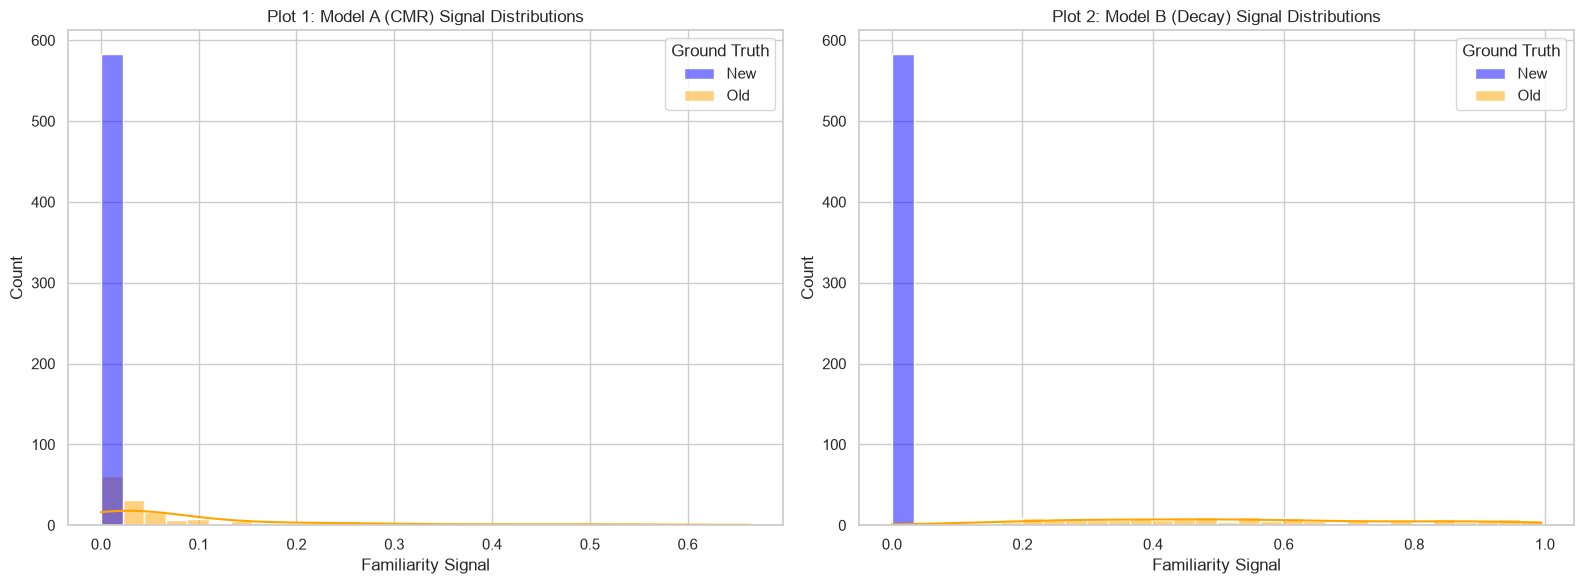

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Model A Distributions
sns.histplot(data=df_sess1, x='sig_A', hue='ISOLDCURRENT', bins=30, kde=True, 
             palette={0: 'blue', 1: 'orange'}, ax=axes[0], alpha=0.5)
axes[0].set_title('Plot 1: Model A (CMR) Signal Distributions')
axes[0].set_xlabel('Familiarity Signal')
axes[0].set_ylabel('Count')
legend = axes[0].get_legend()
if legend:
    legend.set_title('Ground Truth')
    for t, l in zip(legend.texts, ['New', 'Old']):
        t.set_text(l)

# Plot 2: Model B Distributions
sns.histplot(data=df_sess1, x='sig_B', hue='ISOLDCURRENT', bins=30, kde=True, 
             palette={0: 'blue', 1: 'orange'}, ax=axes[1], alpha=0.5)
axes[1].set_title('Plot 2: Model B (Decay) Signal Distributions')
axes[1].set_xlabel('Familiarity Signal')
axes[1].set_ylabel('Count')
legend = axes[1].get_legend()
if legend:
    legend.set_title('Ground Truth')
    for t, l in zip(legend.texts, ['New', 'Old']):
        t.set_text(l)

plt.tight_layout()
plt.show()

#### Plot 3: ROC Curves

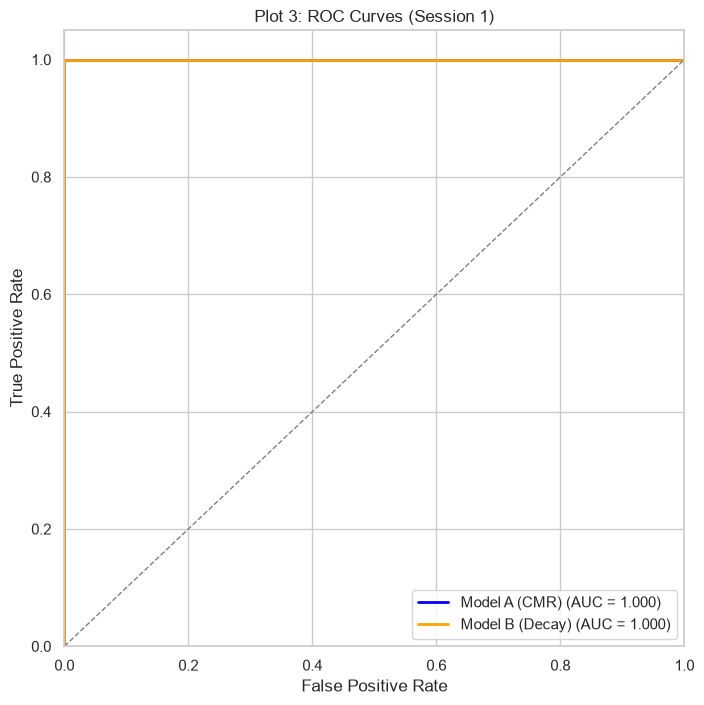

In [15]:
y_true = df_sess1['ISOLDCURRENT'].values
y_score_A = df_sess1['sig_A'].values
y_score_B = df_sess1['sig_B'].values

fpr_A, tpr_A, _ = roc_curve(y_true, y_score_A)
roc_auc_A = auc(fpr_A, tpr_A)

fpr_B, tpr_B, _ = roc_curve(y_true, y_score_B)
roc_auc_B = auc(fpr_B, tpr_B)

plt.figure(figsize=(8, 8))
plt.plot(fpr_A, tpr_A, color='blue', lw=2, label=f'Model A (CMR) (AUC = {roc_auc_A:.3f})')
plt.plot(fpr_B, tpr_B, color='orange', lw=2, label=f'Model B (Decay) (AUC = {roc_auc_B:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Plot 3: ROC Curves (Session 1)')
plt.legend(loc="lower right")
plt.show()

#### Plot 4: Within-Session Context Reinstatement (Preliminary)

We find consecutive Old-Old pairs. When Trial T (Cue) is recognized, does it boost familiarity for Trial T+1 (Target)?

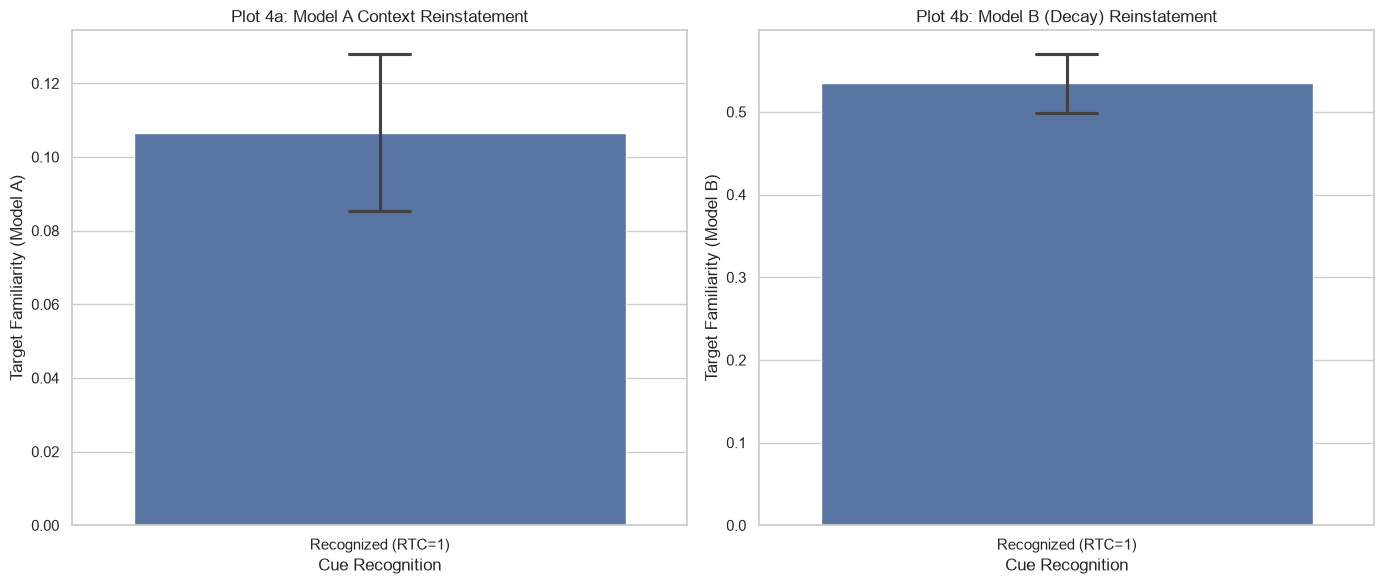

Total Old-Old consecutive pairs found: 48
Cue Recognition
Recognized (RTC=1)    48
Name: count, dtype: int64


In [16]:
# Find pairs where both trial t and trial t+1 are OLD images
is_old = df_sess1['ISOLDCURRENT'].values == 1
# Shift is_old to check the previous trial
prev_is_old = np.roll(is_old, 1)
prev_is_old[0] = False # First trial has no previous

# Valid pairs: both current (Target) and previous (Cue) are Old
valid_pairs = is_old & prev_is_old

# Extract Cue behavior and Target signals for these pairs
# The cue is at index i-1, target at index i
cue_is_correct = df_sess1['ISCORRECT'].values[valid_pairs]
# But wait, we want to know if they recognized the CUE as old. 
# ISCORRECT for an OLD item means they said OLD. So ISCORRECT=1 means RTC=1.
# Let's be precise:
cue_is_old_response = df_sess1['ISOLD'].values[np.roll(valid_pairs, -1)][:-1] # Wait, easier way below

# Let's do it with a loop or index shifting properly
target_indices = np.where(valid_pairs)[0]
cue_indices = target_indices - 1

rtc_status = df_sess1.loc[cue_indices, 'ISOLD'].values
target_sig_A = df_sess1.loc[target_indices, 'sig_A'].values
target_sig_B = df_sess1.loc[target_indices, 'sig_B'].values

# Create DataFrame for plotting
df_pairs = pd.DataFrame({
    'RTC': rtc_status,
    'Model A Target Sig': target_sig_A,
    'Model B Target Sig': target_sig_B
})

# Map RTC to labels
df_pairs['Cue Recognition'] = df_pairs['RTC'].map({0: 'Not Recognized (RTC=0)', 1: 'Recognized (RTC=1)'})

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

sns.barplot(data=df_pairs, x='Cue Recognition', y='Model A Target Sig', ax=axes[0], capsize=.1, errorbar='se')
axes[0].set_title('Plot 4a: Model A Context Reinstatement')
axes[0].set_ylabel('Target Familiarity (Model A)')

sns.barplot(data=df_pairs, x='Cue Recognition', y='Model B Target Sig', ax=axes[1], capsize=.1, errorbar='se')
axes[1].set_title('Plot 4b: Model B (Decay) Reinstatement')
axes[1].set_ylabel('Target Familiarity (Model B)')

plt.tight_layout()
plt.show()

# Print counts
print(f"Total Old-Old consecutive pairs found: {len(df_pairs)}")
print(df_pairs['Cue Recognition'].value_counts())

---
## Phase 2: Scaling Up to All 40 Sessions (Rolling Window)

Now we scale both models across the entire experiment. Because loading a 30,000 x 30,000 matrix takes too much RAM, we use a 39-window rolling approach (Sessions S and S+1).
We will test whether correctly recognizing a Cue image in Session S+1 facilitates recognition of a Target image that was encoded nearby in Session S.

### Step 2.1: Rolling Window Simulation

In [17]:
max_sess = 40
res_df_list = []

print("Starting Rolling Window Simulation...")

for sess_idx in range(1, max_sess):
    s1, s2 = sess_idx, sess_idx + 1
    
    # Get behavioral data for both sessions
    df_window = df[df['SESSION'].isin([s1, s2])].copy()
    df_window = df_window.sort_values('global_idx').reset_index(drop=True)
    
    unique_images = df_window['10KID'].unique()
    n_unique = len(unique_images)
    img_to_idx = {img: idx for idx, img in enumerate(unique_images)}
    df_window['model_idx'] = df_window['10KID'].map(img_to_idx)
    
    # --- Initialize Model A (CMR) ---
    net_A = Network({'loc': {'item': n_unique}}, {'loc': {'item': n_unique}})
    identity_mat = np.eye(n_unique)
    net_A.add_pre_weights('fc', ('loc', 'item'), ('loc', 'item'), identity_mat)
    net_A.add_pre_weights('cf', ('loc', 'item'), ('loc', 'item'), identity_mat)
    
    # --- Initialize Model B (Decay) ---
    memory_strength = np.zeros(n_unique)
    
    sig_A_list = np.zeros(len(df_window))
    sig_B_list = np.zeros(len(df_window))
    seen_images = set()
    
    current_session = s1
    
    for i, row in df_window.iterrows():
        # Session gap handling: Reset CMR context
        if row['SESSION'] != current_session:
            net_A.c[:] = 0
            current_session = row['SESSION']
            # Note: For Model B, we apply no extra decay across the week gap for simplicity
            
        item_idx = int(row['model_idx'])
        
        # READOUT
        sig_A_list[i] = np.dot(net_A.c, net_A.w_cf_exp)[item_idx]
        sig_B_list[i] = memory_strength[item_idx]
        
        # UPDATE
        if item_idx not in seen_images:
            net_A.present(('loc', 'item', item_idx), 'loc', B_enc, Lfc, Lcf)
            memory_strength[item_idx] = refresh_strength
            seen_images.add(item_idx)
        else:
            net_A.integrate(('loc', 'item', item_idx), 'loc', B_enc)
            memory_strength[item_idx] = refresh_strength
            
        # DECAY (Model B)
        memory_strength *= decay_rate
        
    # Save signals
    df_window['sig_A'] = sig_A_list
    df_window['sig_B'] = sig_B_list
    
    # Keep only Session S+1 trials to avoid double-counting Session S
    df_res = df_window[df_window['SESSION'] == s2].copy()
    res_df_list.append(df_res)
    
    print(f"Completed window {s1}-{s2}")

res_df_global = pd.concat(res_df_list, ignore_index=True)
print("Simulation complete! Total trials evaluated:", len(res_df_global))

Starting Rolling Window Simulation...


Completed window 1-2


Completed window 2-3


Completed window 3-4


Completed window 4-5


...

Completed window 35-36


Completed window 36-37


Completed window 37-38


Completed window 38-39


Completed window 39-40
Simulation complete! Total trials evaluated: 29250


### Step 2.2: Identify Cue-Target Pairs

We search for pairs where Cue (Image A) and Target (Image B) were originally encoded in Session S within `max_lag` trials of each other, and both reappear in Session S+1, with the Cue appearing *before* the Target.

In [18]:
max_lag = 10
pairs_data = []

print("Extracting Cue-Target pairs...")

for sess_idx in range(1, max_sess):
    s1, s2 = sess_idx, sess_idx + 1
    
    df_s1 = df[df['SESSION'] == s1].sort_values('global_idx').reset_index(drop=True)
    df_s2 = res_df_global[res_df_global['SESSION'] == s2].sort_values('global_idx').reset_index(drop=True)
    
    # Find images shown in Session S1 (Presentation 1)
    s1_pres1 = df_s1[df_s1['presentation_number'] == 1]
    
    # Create mapping of ImageID -> S1 index
    s1_idx_map = dict(zip(s1_pres1['10KID'], s1_pres1.index))
    
    # Iterate through S2 trials
    for target_i, target_row in df_s2.iterrows():
        # Target must be old (presentation 2 or 3)
        if target_row['ISOLDCURRENT'] != 1:
            continue
            
        target_id = target_row['10KID']
        if target_id not in s1_idx_map:
            continue
            
        target_s1_idx = s1_idx_map[target_id]
        
        # Look for a Cue that appeared BEFORE this Target in S2
        df_s2_before = df_s2.iloc[:target_i]
        cues_before = df_s2_before[df_s2_before['ISOLDCURRENT'] == 1]
        
        for cue_i, cue_row in cues_before.iterrows():
            cue_id = cue_row['10KID']
            if cue_id not in s1_idx_map:
                continue
                
            cue_s1_idx = s1_idx_map[cue_id]
            
            # Check lag in S1
            lag = abs(target_s1_idx - cue_s1_idx)
            
            if 0 < lag <= max_lag:
                # Valid pair!
                pairs_data.append({
                    'Session': s2,
                    'Cue_ID': cue_id,
                    'Target_ID': target_id,
                    'Lag': lag,
                    'RTC': cue_row['ISCORRECT'], # 1 if human correctly recognized Cue, else 0
                    'Model_A_Target_Sig': target_row['sig_A'],
                    'Model_B_Target_Sig': target_row['sig_B'],
                    'Target_ISCORRECT': target_row['ISCORRECT'] # Human target accuracy
                })
                # Once we find one valid cue for this target, we can break or collect all. 
                # For simplicity, we break to keep pairs 1-to-1 where possible.
                break

pairs_df = pd.DataFrame(pairs_data)
print(f"Found {len(pairs_df)} valid Cue-Target pairs across all sessions.")
display(pairs_df.head())

Extracting Cue-Target pairs...


Found 158 valid Cue-Target pairs across all sessions.


,Session,Cue_ID,Target_ID,Lag,RTC,Model_A_Target_Sig,Model_B_Target_Sig,Target_ISCORRECT
0,2,1386.0,5273.0,7,1.0,0.131496,0.882220,1.0
1,2,1218.0,1069.0,1,1.0,0.071370,0.518589,1.0
2,2,1386.0,5102.0,10,1.0,0.355404,0.936915,1.0
3,2,5273.0,8706.0,10,1.0,0.027076,0.095764,1.0
4,2,14.0,4211.0,3,1.0,0.012992,0.128718,1.0


### Step 2.3: Evaluation Plots (Plots 5-10)

First, let's establish the overall recognition performance.

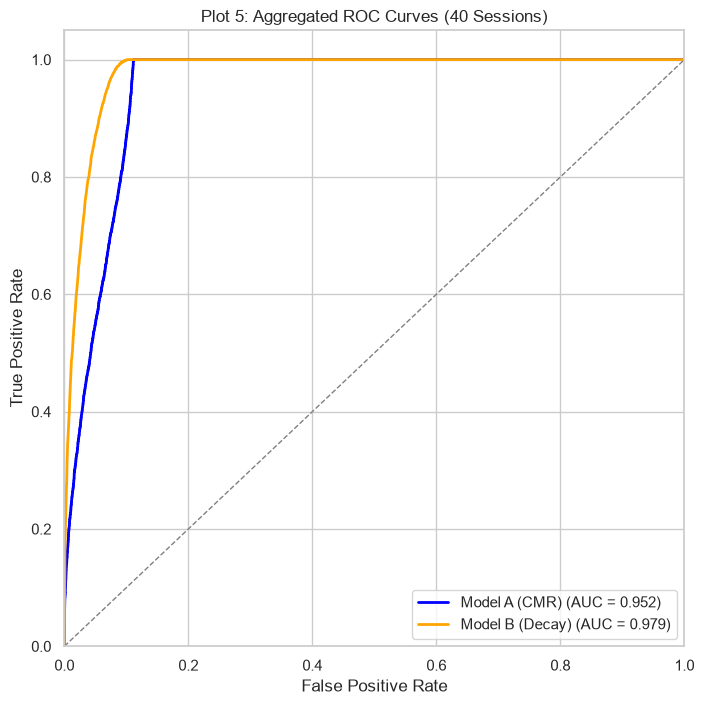

In [19]:
# Plot 5: Aggregated ROC Curves
y_true = res_df_global['ISOLDCURRENT'].values
y_score_A = res_df_global['sig_A'].values
y_score_B = res_df_global['sig_B'].values

fpr_A, tpr_A, _ = roc_curve(y_true, y_score_A)
roc_auc_A = auc(fpr_A, tpr_A)

fpr_B, tpr_B, _ = roc_curve(y_true, y_score_B)
roc_auc_B = auc(fpr_B, tpr_B)

plt.figure(figsize=(8, 8))
plt.plot(fpr_A, tpr_A, color='blue', lw=2, label=f'Model A (CMR) (AUC = {roc_auc_A:.3f})')
plt.plot(fpr_B, tpr_B, color='orange', lw=2, label=f'Model B (Decay) (AUC = {roc_auc_B:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Plot 5: Aggregated ROC Curves (40 Sessions)')
plt.legend(loc="lower right")
plt.show()

#### Plot 6: AUC Per Session

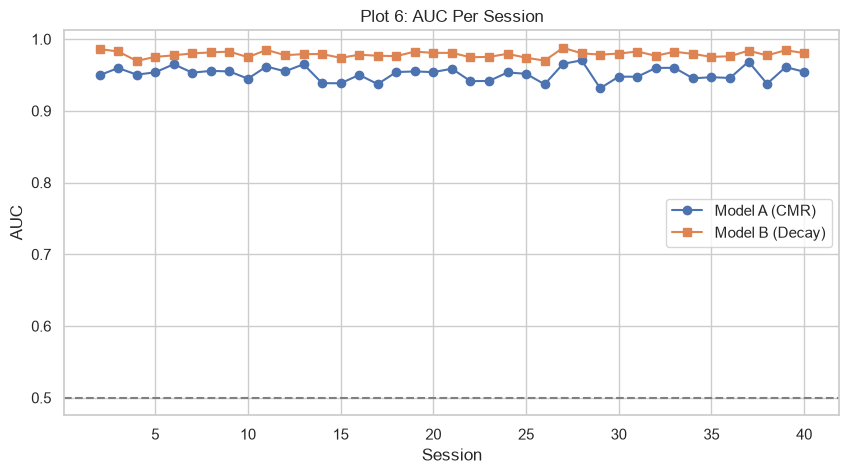

In [20]:
# Plot 6: AUC Per Session
sessions = []
auc_A_list = []
auc_B_list = []

for s in range(2, max_sess + 1):
    df_s = res_df_global[res_df_global['SESSION'] == s]
    if len(df_s) == 0 or len(df_s['ISOLDCURRENT'].unique()) < 2: continue
    
    fpr, tpr, _ = roc_curve(df_s['ISOLDCURRENT'], df_s['sig_A'])
    auc_A_list.append(auc(fpr, tpr))
    
    fpr, tpr, _ = roc_curve(df_s['ISOLDCURRENT'], df_s['sig_B'])
    auc_B_list.append(auc(fpr, tpr))
    sessions.append(s)

plt.figure(figsize=(10, 5))
plt.plot(sessions, auc_A_list, marker='o', label='Model A (CMR)')
plt.plot(sessions, auc_B_list, marker='s', label='Model B (Decay)')
plt.axhline(0.5, color='gray', linestyle='--')
plt.xlabel('Session')
plt.ylabel('AUC')
plt.title('Plot 6: AUC Per Session')
plt.legend()
plt.show()

#### Plots 7 & 8: Target Familiarity by Cue Recognition Status (RTC Effect)

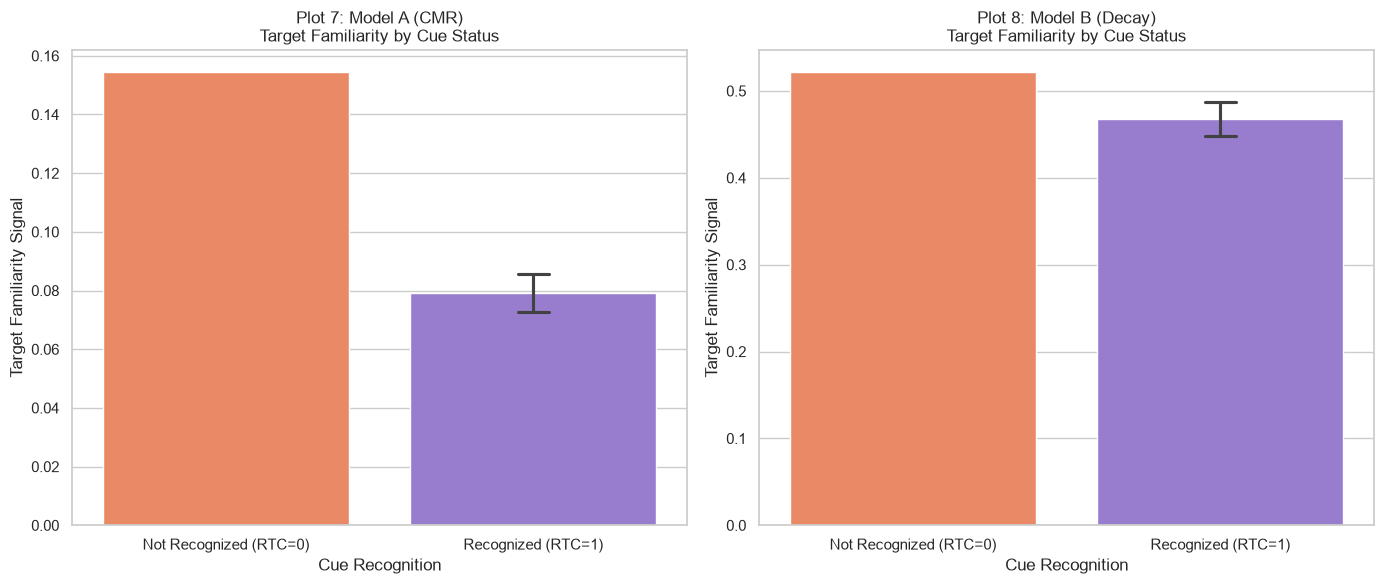

In [21]:
# Plots 7 & 8: Target Familiarity by RTC
df_plot = pairs_df.copy()
df_plot['Cue Recognition'] = df_plot['RTC'].map({0: 'Not Recognized (RTC=0)', 1: 'Recognized (RTC=1)'})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=df_plot, x='Cue Recognition', y='Model_A_Target_Sig', ax=axes[0], capsize=.1, errorbar='se', palette=['coral', 'mediumpurple'], order=['Not Recognized (RTC=0)', 'Recognized (RTC=1)'])
axes[0].set_title('Plot 7: Model A (CMR)\nTarget Familiarity by Cue Status')
axes[0].set_ylabel('Target Familiarity Signal')

sns.barplot(data=df_plot, x='Cue Recognition', y='Model_B_Target_Sig', ax=axes[1], capsize=.1, errorbar='se', palette=['coral', 'mediumpurple'], order=['Not Recognized (RTC=0)', 'Recognized (RTC=1)'])
axes[1].set_title('Plot 8: Model B (Decay)\nTarget Familiarity by Cue Status')
axes[1].set_ylabel('Target Familiarity Signal')

plt.tight_layout()
plt.show()

#### Plots 9 & 10: Contiguity Gradient & Effect Size Comparison

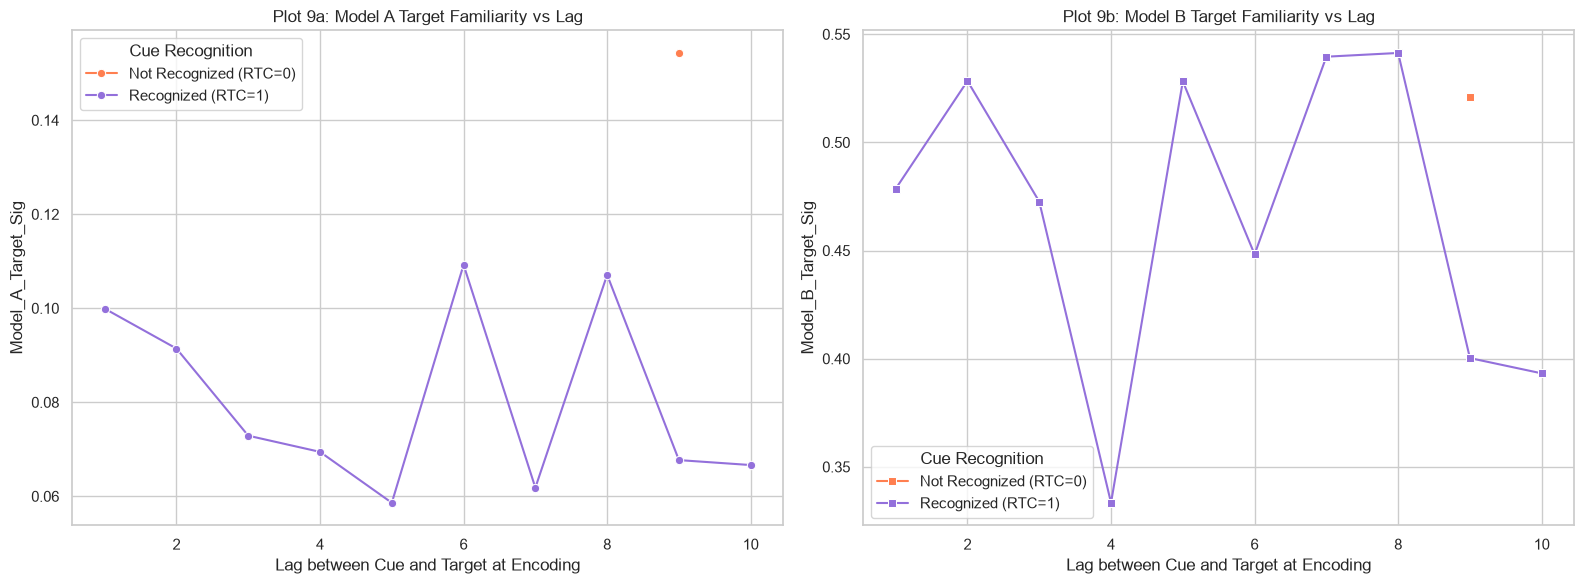

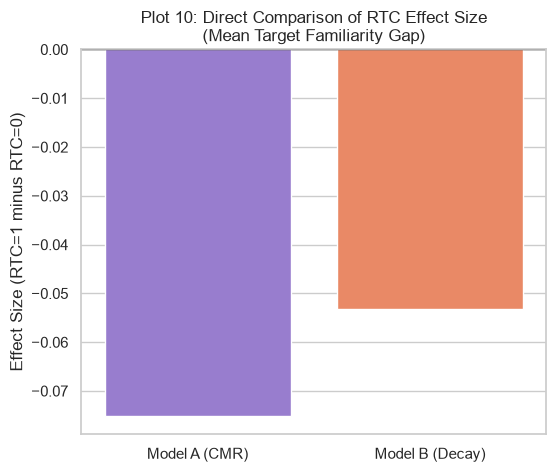

In [22]:
# Plot 9: RTC Effect as a function of lag
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(data=df_plot, x='Lag', y='Model_A_Target_Sig', hue='Cue Recognition', marker='o', ax=axes[0], palette=['coral', 'mediumpurple'], errorbar=None, hue_order=['Not Recognized (RTC=0)', 'Recognized (RTC=1)'])
axes[0].set_title('Plot 9a: Model A Target Familiarity vs Lag')
axes[0].set_xlabel('Lag between Cue and Target at Encoding')

sns.lineplot(data=df_plot, x='Lag', y='Model_B_Target_Sig', hue='Cue Recognition', marker='s', ax=axes[1], palette=['coral', 'mediumpurple'], errorbar=None, hue_order=['Not Recognized (RTC=0)', 'Recognized (RTC=1)'])
axes[1].set_title('Plot 9b: Model B Target Familiarity vs Lag')
axes[1].set_xlabel('Lag between Cue and Target at Encoding')

plt.tight_layout()
plt.show()

# Plot 10: RTC Effect Size
rtc1_mean_A = df_plot[df_plot['RTC'] == 1]['Model_A_Target_Sig'].mean()
rtc0_mean_A = df_plot[df_plot['RTC'] == 0]['Model_A_Target_Sig'].mean()
eff_A = rtc1_mean_A - rtc0_mean_A

rtc1_mean_B = df_plot[df_plot['RTC'] == 1]['Model_B_Target_Sig'].mean()
rtc0_mean_B = df_plot[df_plot['RTC'] == 0]['Model_B_Target_Sig'].mean()
eff_B = rtc1_mean_B - rtc0_mean_B

plt.figure(figsize=(6, 5))
sns.barplot(x=['Model A (CMR)', 'Model B (Decay)'], y=[eff_A, eff_B], palette=['mediumpurple', 'coral'])
plt.axhline(0, color='black', linewidth=1)
plt.title('Plot 10: Direct Comparison of RTC Effect Size\n(Mean Target Familiarity Gap)')
plt.ylabel('Effect Size (RTC=1 minus RTC=0)')
plt.show()

#### The Primary Hypothesis Plots (Plots 11 & 12)

To compute "Target Recognition Accuracy", we need an optimal threshold for each model to convert continuous familiarity into a binary Old/New decision. We use Youden's J statistic (argmax TPR - FPR) on the full dataset ROC curve.

Model A Optimal Threshold: 0.0000
Model B Optimal Threshold: 0.0580


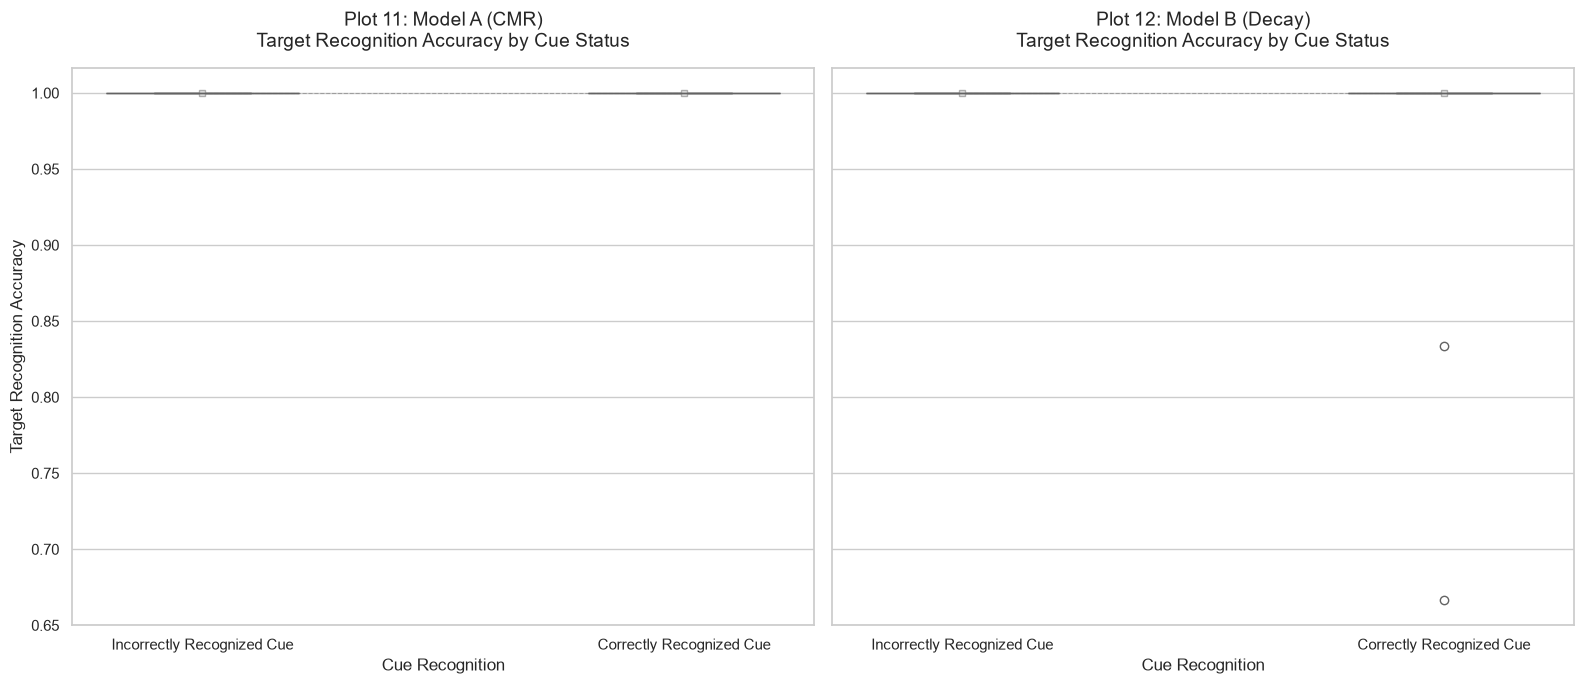

--- Average Target Accuracy (across all valid sessions) ---
Model A (CMR):
RTC
0.0    1.0
1.0    1.0
Name: Model_A_Accuracy, dtype: float64

Model B (Decay):
RTC
0.0    1.000000
1.0    0.987179
Name: Model_B_Accuracy, dtype: float64


In [23]:
# Find Optimal Thresholds using Youden's J statistic
fpr_A, tpr_A, thresholds_A = roc_curve(y_true, y_score_A)
optimal_idx_A = np.argmax(tpr_A - fpr_A)
optimal_threshold_A = thresholds_A[optimal_idx_A]

fpr_B, tpr_B, thresholds_B = roc_curve(y_true, y_score_B)
optimal_idx_B = np.argmax(tpr_B - fpr_B)
optimal_threshold_B = thresholds_B[optimal_idx_B]

print(f"Model A Optimal Threshold: {optimal_threshold_A:.4f}")
print(f"Model B Optimal Threshold: {optimal_threshold_B:.4f}")

# Convert Target Familiarity to binary accuracy (1 = Correctly identified as Old, 0 = Missed)
pairs_df['Model_A_Accuracy'] = (pairs_df['Model_A_Target_Sig'] >= optimal_threshold_A).astype(int)
pairs_df['Model_B_Accuracy'] = (pairs_df['Model_B_Target_Sig'] >= optimal_threshold_B).astype(int)

# Group by Session and RTC to get mean accuracy per session
session_acc = pairs_df.groupby(['Session', 'RTC'])[['Model_A_Accuracy', 'Model_B_Accuracy', 'Target_ISCORRECT']].mean().reset_index()
session_acc['Cue Recognition'] = session_acc['RTC'].map({0: 'Incorrectly Recognized Cue', 1: 'Correctly Recognized Cue'})

# Helper function to plot matched boxplots
def plot_matched_boxplots(data, y_col, title, ax, color_palette):
    sns.boxplot(data=data, x='Cue Recognition', y=y_col, ax=ax, width=0.4, palette=color_palette, order=['Incorrectly Recognized Cue', 'Correctly Recognized Cue'])
    
    # Add connecting lines for each session
    sessions = data['Session'].unique()
    for s in sessions:
        s_data = data[data['Session'] == s]
        if len(s_data) == 2: # Must have both RTC=0 and RTC=1
            y0 = s_data[s_data['RTC'] == 0][y_col].values[0]
            y1 = s_data[s_data['RTC'] == 1][y_col].values[0]
            ax.plot([0, 1], [y0, y1], color='gray', linestyle='--', linewidth=0.8, alpha=0.6, marker='s', markersize=4, markerfacecolor='lightgray')

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Plot 11: Model A
plot_matched_boxplots(session_acc, 'Model_A_Accuracy', '', axes[0], {'Incorrectly Recognized Cue': 'coral', 'Correctly Recognized Cue': 'mediumpurple'})
axes[0].set_title('Plot 11: Model A (CMR)\nTarget Recognition Accuracy by Cue Status', fontsize=14, pad=15)
axes[0].set_ylabel('Target Recognition Accuracy', fontsize=12)
axes[0].set_xlabel('Cue Recognition', fontsize=12)

# Plot 12: Model B
plot_matched_boxplots(session_acc, 'Model_B_Accuracy', '', axes[1], {'Incorrectly Recognized Cue': 'coral', 'Correctly Recognized Cue': 'mediumpurple'})
axes[1].set_title('Plot 12: Model B (Decay)\nTarget Recognition Accuracy by Cue Status', fontsize=14, pad=15)
axes[1].set_xlabel('Cue Recognition', fontsize=12)

plt.tight_layout()
plt.show()

# Print statistical summary
print("--- Average Target Accuracy (across all valid sessions) ---")
print("Model A (CMR):")
print(session_acc.groupby('RTC')['Model_A_Accuracy'].mean())
print("\nModel B (Decay):")
print(session_acc.groupby('RTC')['Model_B_Accuracy'].mean())